# Project

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [22]:
url = "https://raw.githubusercontent.com/anjali801/Data-science-45-internship/main/archive/biotech_funding.csv"
data = pd.read_csv(url)


In [23]:
df = pd.DataFrame(data)
print(df)

     deal_id        date  year  deal_type acquirer_or_investors  \
0      D0001  2009-03-09  2009        M&A                Pfizer   
1      D0041  2010-01-08  2010   Series_B       F-Prime Capital   
2      D0036  2010-01-12  2010        IPO        Public markets   
3      D0045  2010-01-16  2010        M&A                 Roche   
4      D0053  2010-01-17  2010   Series_B      Polaris Partners   
...      ...         ...   ...        ...                   ...   
1203   D1207  2026-02-07  2026         VC               OrbiMed   
1204   D1203  2026-04-02  2026   Series_B         Atlas Venture   
1205   D1208  2026-04-13  2026         VC   Flagship Pioneering   
1206   D1204  2026-04-16  2026  Crossover              a16z Bio   
1207   D1205  2026-04-17  2026   Series_C   Flagship Pioneering   

        target_or_company  value_usd_bn              description  is_megadeal  \
0                   Wyeth        68.000  Pfizer-Wyeth megamerger            1   
1               Oncgen OS        

In [24]:
# find no of rows and columns :
df.shape

(1208, 10)

In [25]:
df.isnull().sum()

,0
deal_id,0
date,0
year,0
deal_type,0
acquirer_or_investors,0
target_or_company,0
value_usd_bn,0
description,0
is_megadeal,0
is_real_headline,0


In [26]:
df1 = df.drop(columns = [ 'deal_id',
    'description',
    'target_or_company',
    'date'] , inplace = True )
df

,year,deal_type,acquirer_or_investors,value_usd_bn,is_megadeal,is_real_headline
0,2009,M&A,Pfizer,68.000,1,1
1,2010,Series_B,F-Prime Capital,0.403,0,0
2,2010,IPO,Public markets,0.456,0,0
3,2010,M&A,Roche,1.158,0,0
4,2010,Series_B,Polaris Partners,0.643,0,0
...,...,...,...,...,...,...
1203,2026,VC,OrbiMed,0.065,0,0
1204,2026,Series_B,Atlas Venture,0.122,0,0
1205,2026,VC,Flagship Pioneering,0.229,0,0
1206,2026,Crossover,a16z Bio,0.183,0,0


In [36]:
# split Data :
#  (Independent Variables)
x = data[['year', 'is_megadeal', 'is_real_headline']]

# (Dependent Variable)
y = data['value_usd_bn']

# featurn scaling
scaler = StandardScaler()
x[['year', 'is_megadeal', 'is_real_headline']] = scaler.fit_transform(
    x[['year', 'is_megadeal', 'is_real_headline']]
)
# Scale the numerical columns only
scaler = StandardScaler()
x = scaler.fit_transform(x)



# Train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=2)


# model train
model = LinearRegression()
model.fit(x_train,y_train)

# Prediction
y_pred = model.predict(x_test)
print(y_pred)

#model dump
!pip install joblib
import joblib
joblib.dump(model,'biotech.joblib')

/tmp/ipykernel_2363/2319213730.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[['year', 'is_megadeal', 'is_real_headline']] = scaler.fit_transform(


[ 0.42538661  0.44771727  0.45329994  0.39747329  0.45329994  0.45329994
  0.4756306   0.41980395  0.41980395  0.41980395  0.4588826   0.41980395
  0.44213461  0.41980395  0.43655194  0.43655194  0.4588826   0.40863862
  0.42538661  0.4588826   0.45329994  0.43655194  0.44213461  0.40305595
  0.43655194  0.44771727 28.77744657  0.43655194  0.42538661  0.40305595
  0.39747329  0.42538661  0.44213461 28.7718639   0.39747329  0.40863862
  2.78625495  0.45329994  0.43655194  0.39747329  0.39747329  0.40305595
  0.43655194 28.79977723  0.44213461  0.41980395  0.39747329  0.45329994
  0.43655194  0.44213461  0.44771727  0.39747329  0.46446527  0.4756306
  0.41422128  0.39747329  0.45329994  0.44213461  0.39747329  0.41422128
  0.42538661  0.40863862 28.77744657  0.40305595  0.44213461  0.44213461
  0.43655194  0.39747329  0.4756306   0.45329994  0.41980395  0.47004793
 26.38866491  0.44213461  0.47004793  0.40863862  0.43655194  0.41980395
  0.42538661  0.44771727  0.48121326  0.43655194  0.

['biotech.joblib']

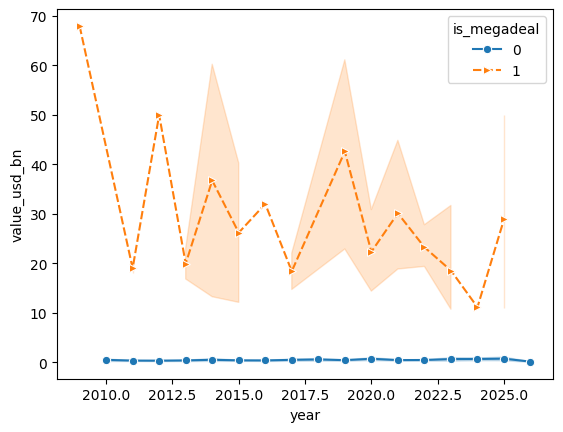

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x='year', y='value_usd_bn', data=df , hue = "is_megadeal" , style ="is_megadeal" , markers= ["o",">"])
plt.show()